![Photograph: Zakir Hossain Chowdhury / Barcro](/data/villagers_migrating_bangladesh.jpg){fig-alt="Villagers on dried river bed in Satkhira, Bangladesh." width="100%"}

Haven't we all thought about moving to another location during several occasions in our lives? Probably, more than once. May be we got a better job offer in another city or a country. Maybe our country is devasted by wars and ethnic conflicts, and we don't feel safe in its territory. Maybe our place faced severe climatic conditions, and there remained no means to sustain life. For one reason or another, humans have been moving across the globe. Our ancestors moved around engaging in business, seeking favorable climatic conditions, waging wars, and building settlements. 

As a species, humans tend to be a very mobile species. It has been ages since we started migrating. The first migration of modern humans from Africa dates back to 70,000 to 100,000 years ago. Yes, it has been a long time, and we still have not stopped migrating. However, the patterns, drivers, and impacts of migration have changed over time. While it is impossible to track the personal stories of every migrating individual, because of the collective systems in which we live and behave, it is possible to study and generalize the overall story of how and why we might be migrating. This blog is an attempt to explore the modern trends in migrations since 2000 till 2022 with respect to economy, socio-political conflicts, and human rights of displaced populations.

::: {.callout-note icon=false}

## Research Questions

* Which countries are the top destinations? 
* Where do the large emigrating populations come from?
* Which migrating populations are seeking naturalization in their destinations? 
* Are there any national/ethnic/environmental reasons that explain the migration of some populations? 
* How are migrating populations connected to the economy of their birth countries and the destinations? 
* Are there any policies that favor human mobility? 

:::





# Data Description

The datasets that will be used to study the migration dynamics will be obtained from the "Organization of Economic Cooperation and Development (OECD)" and the "The Global Knowledge Partnership on Migration and Development (KNOMAD)".
The [dataset](https://stats.oecd.org/Index.aspx?DataSetCode=MIG) from OECD will contain the migration rate--recorded as the number of individuals migrating from one country to another--across 2000 to 2022 where as [KNOMAD's datasets](https://www.knomad.org/data/remittances) contains the information about the remittance of a country. *Remittance is the capital received by a country from their native populations working overseas*.

The OECD dataset has measures of non-native populations entering into (inflows) and leaving from (outflows) the top destinations. These measures are based on population registers, residence and/or work permits, and estimation from surveys.

The general view of the data in OECD dataset is shown in @tbl-migration


In [1]:
#| label: tbl-migration
#| tbl-cap: Migration Flows
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
flows = pd.read_csv("../data/inflows of foreign population by nationality.csv", low_memory=False)
# dropping null values
flows = flows.dropna(subset=['Value'])
flows_cleaned = flows.dropna(subset=['Value'])

# dropping columns that we don't need
flows_cleaned = flows.drop(columns=['Flag Codes', 'Flags'])
flows_cleaned.head()

,CO2,Country of birth/nationality,VAR,Variable,GEN,Gender,COU,Country,YEA,Year,Value
0,AFG,Afghanistan,B11,Inflows of foreign population by nationality,TOT,Total,AUS,Australia,2000,2000,887.0
1,AFG,Afghanistan,B11,Inflows of foreign population by nationality,TOT,Total,AUS,Australia,2001,2001,456.0
2,AFG,Afghanistan,B11,Inflows of foreign population by nationality,TOT,Total,AUS,Australia,2002,2002,660.0
3,AFG,Afghanistan,B11,Inflows of foreign population by nationality,TOT,Total,AUS,Australia,2003,2003,1015.0
4,AFG,Afghanistan,B11,Inflows of foreign population by nationality,TOT,Total,AUS,Australia,2004,2004,1340.0


:::{.callout-note}
The `variable` column contains two unique labels. `Inflows of foreign population by nationality` tells the number of people arriving at a `country` from their birth countries. `Outflows of foreign population by nationality` tells the number of non-native population leaving for their birth country from a `country`.
:::

The general overview of the remittance sent out by a country is shown in @tbl-remittance.


In [2]:
#| label: tbl-remittance
#| tbl-cap: Remittance Outflows
import pandas as pd

#remittance sent out by a country
remitance = pd.read_excel("../data/outward-remittance-flows-brief-39-december-2023-revised-as-of-mar.8-2024_1.xlsx", header = 1, index_col= None)

#dropping null values
remitance = remitance.dropna()
remitance.head()

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

::: {.callout-note}
Remittance, in this context, is defined as the sum of money sent by a person working abroad back to their birth country. 
:::

Another dataset on remittance is for the remittance received by a country which is shown in @tbl-remittance_in


In [ ]:
#| label: tbl-remittance_in
#| tbl-cap: Remittance Inflows

remit_inward = pd.read_excel("../data/inward_remittance_flows_december_2023_1.xlsx")
#dropping null values
remit_inward = remit_inward.dropna()
remit_inward.head()

,Remittance inflows (US$ million),2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023e,% of GDP in 2023
0,Afghanistan,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,89.500000,...,348.624717,627.710802,822.731630,803.546454,828.571904,788.917115,320.000000,370.000000,300.000000,2.007898
1,Albania,597.8,699.3,733.57,888.748582,1160.672105,1289.704316,1359.467325,1468.020000,1865.600000,...,1290.863508,1306.009167,1311.822432,1458.210056,1472.812242,1465.987212,1718.355918,1745.245136,1970.000000,8.553317
2,Algeria,0.0,0.0,0.00,0.000000,0.000000,170.000000,189.000000,99.004563,103.631887,...,1997.393458,1989.023597,1791.887073,1984.998399,1785.838683,1699.608935,1792.158957,1658.975810,1770.000000,0.790179
4,Andorra,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,21.100000,47.416324,53.001418,0.000000,0.000000,0.000000
5,Angola,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,82.084000,...,11.114712,3.988048,1.418196,1.579247,3.445473,8.053051,12.631149,14.005491,14.688758,0.015660


We will use these datasets for the rest of our studies.



### Emigrating Population

:::{.callout-note}
Migration can be understood as the movement of people in and out of a country. Moving in of non-native populations and moving out of native population can happen simultaneously in a country.
:::


Emigrating population can be defined as the population that is leaving their native country and is moving into a new country. The reasons and motive for such outflows can be several, including employment opportunities, political conflicts, refugees, and so on. The datasets we are using in this project do not have comprehensive information to study the actual reasons behind the migrations, but we will later look into employment opportunities in countries that receive highest number of emigrants. Other reasons can also be empirically implied based on the conditions at the time of migration in their former countries. For instance, we can expect a bigger number of people leaving a country with ongoing war or political conflicts or a climate disaster. First, let's see the general trend in emigrating population. The @fig-inflows shows the total number of foreign individuals arriving in a destination (for instance, United States) over time. 


In [ ]:
#| label: fig-inflows
#| fig-cap: Total emigrating population in a given year. *The daset is limited to OECD countries as destinations for migrants*.

# focusing on inflowing population
inflows_cleaned = flows_cleaned[flows_cleaned['Variable'] == 'Inflows of foreign population by nationality']
#dropping total values for a year and a country from the df
inflows_cleaned = inflows_cleaned[inflows_cleaned['Country of birth/nationality'] != "Total"]

#choropleth

fig = px.choropleth(
    data_frame=inflows_cleaned.groupby(['COU', 'Year', "Country"], as_index=False)['Value'].sum(),
    locations="COU",
    animation_frame="Year",
    animation_group = "COU",
    color="Value",
    title="Inflows of Foreign Population",
    color_continuous_scale="Viridis",
    projection="equirectangular", 
    labels={"Value": "Migration Value"},
    hover_name="Country",
    template="ggplot2",
)

fig.show()

This figure does not indicate where all these moving populations originate from. The figure only shows the total number of immigrants arriving at a destination in a given year. So it would be even more interesting to see where these populations are arrriving from. In @fig-2020in, for brevity and effective communication of information in a compact graph, we will focus only on the top 20 movements in 2020. 

![Total Emigrating Population in 2020, both origins and destinations(arrows) indicated](top_10_migration_inflows_2020.png){#fig-2020in}

The above figure shows a very interesting trend in Europe. Germany tends to be the favorite destination among many European nations (Bulgaria, Italy, Romania, Croatia, Poland). There is a large movement from Ukrain to Poland as well. The Syrian populations from West Asia also migrate to Germany in huge numbers. The migration from Syria might be the cause of civil unrest within the country while other migrations within the European nations might be due to the open borders among Schengen nations. 

While European nations mostly see intracontinental migrations, other destinations seem to have cross-continental migration. People from India are migrating to US and Canada in 2020. Populations from China also migrate into the US. Spain receives populations from Morocco and Brazil while Portugal receives populations from Colombia. There are continental migrations in other continents as well (Mexico to USA, Venezuela to Chile, China to Korea and Japan, Viet Nam to Japan), but they are not as consistent as in Europe (see @fig-flows).

Rather than just focusing in the year 2020, seeing the total inflows over time might be better to see the trend. The aggregate is calculated for the top 10 moving populations from 2000-2020 and is visualized with their origin and destination countries in the @fig-topmeans.


In [ ]:
#| label: fig-topmeans
#| fig-cap: Top Mean Inflows of Population in 2000-2020.

# total inflows till 2020
total_inflows_10 = inflows_cleaned[inflows_cleaned['Year'] <= 2020]
total_inflows_10 = total_inflows_10[total_inflows_10['CO2'] != 'Total']

# total inflows from a country to another country (grouped)
total_inflows_10 = total_inflows_10.groupby(['Country of birth/nationality', 'Country'])['Value'].sum().reset_index(name='Total Migration')

# some countries have larget moving populations moving to different locations, so 16 and not 10
top_10_inflows = total_inflows_10.nlargest(16, "Total Migration")
# sorting them in descending order
sorted_top_10_inflows = top_10_inflows.sort_values('Total Migration', ascending=False)

# drawing parallel categories

fig = px.parallel_categories(
    data_frame=sorted_top_10_inflows,
    dimensions=['Country of birth/nationality', 'Country'],
    color='Total Migration',
    color_continuous_scale=px.colors.sequential.Viridis,
    labels={
        'Country of birth/nationality': 'Birth Country',
        'Country': 'Destination Country'
    }
)
fig.update_layout(
    title="Top 10 Population Leaving their Birth Country in 2000-2020",
    title_x=0.5,
    coloraxis_colorbar=dict(x=1.1),
    margin=dict(l=100, t = 80) # adjust margins on the left and top
)
fig.show()

As the figure suggests, Germany and US are the top destinations for many migrating populations. As was seen in 2020, the top moving populations are very similar on average from 2000-2022 time period. So it can be assumed that the dynamics between these countries will continue in the future as well, disregarding any unprecedented events like wars or changes in policies.

:::{.callout-caution}
It is important to take all the conclusions made based on the `total number` with caution. A small country from where 60% of the native population are leaving can still have fewer migrants in number compared to a country with a larger population from where only 5% of its total population are moving. The former case is more alarming even if fewer people are migrating. So studying in terms of more representative measures (such as ratio of the total population) will be more scientific. 
:::

At this point, after exploring the top emigrating populations and destinations, we might assume that the total migration into these destination have increased over time. So it might be a good idea to test our intuitive  assumption about the change in emigrating population over time in top destinations. The change in total inflows is depicted for the United States, Korea, Japan, Germany, Italy, and Canada in @fig-overtime.


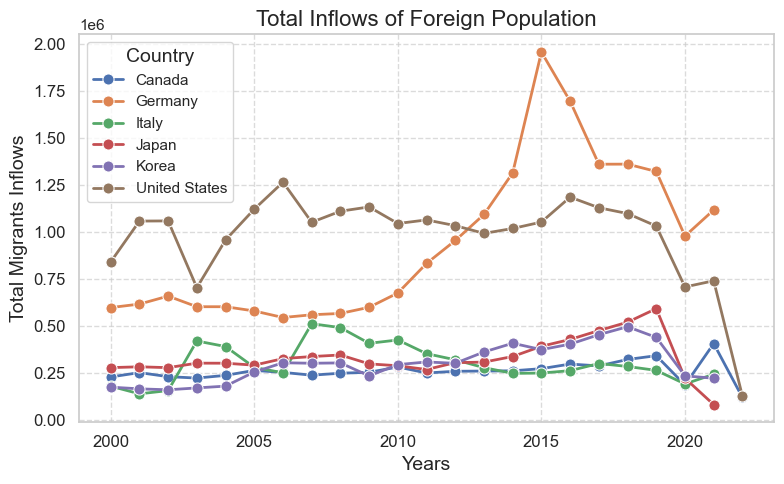

In [ ]:
#| label: fig-overtime
#| fig-cap: ' Total Inflows Over Time'

# only selected few top destinations

top_countries = ["United States", "Korea", "Japan", "Germany", "Italy", "Canada"]
inflows_top_countries = inflows_cleaned[inflows_cleaned['Country'].isin(top_countries)]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

# plotting line graph

sns.lineplot(data=inflows_top_countries, x="Year", y="Value", hue="Country", estimator=sum, errorbar=None, marker="o", markersize=8, linewidth=2)

plt.title("Total Inflows of Foreign Population", fontsize=16)
plt.xlabel("Years", fontsize=14)
plt.ylabel("Total Migrants Inflows", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.7)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.legend(title="Country", title_fontsize='14', loc='upper left')

plt.tight_layout()
plt.show()

As shown in @fig-overtime, there is no stark differences in total inflows over time among these countries expect in Germany. During 2015, there was a large inflow of foreign population compared to the previous years. According to a research, this was attributed to the European refugee crisis "when the flow of migrants increased dramatically from 153,000 in 2008 to more than 1 million in 2015. This was mainly due to the growing number of Syrians, Iraqis, Libyans, Afghans and Eritreans fleeing war, ethnic conflict or economic hardship" (@peters2023). 


#### Naturalization

When we talk about the emigrating populations, naturalization is also part of the conversation. **Naturalization is a process by wich a non-national citizen acquires the nationality of a certain country.** The tendency to seek nationality in a country can have personal motives but it also can be reflective of the conditions in migrants' birth countries. For instance, migrants fleeing wars, ethnic discrimination, and climate disasters will likely seek permanent settlements in their new destinations. There are two players in this dynamics: the country granting citizenship and the country to which migrants belong to.  The @fig-granting shows the top five countries granting nationality over time. We have line graphs for eight countries, which means that the top five grantees of nationality in any given year from 2000-2022 are among these eight countries.


In [ ]:
#| label: fig-granting
#| fig-cap: ' Top countries granting citizenships to non-native populations.'


data = pd.read_csv("../data/inflows of foreign population by nationality.csv", low_memory=False)

# subsetting only acquisition variables

nationality_acquisition = data[data['Variable'] == "Acquisition of nationality by country of former nationality"]

# calculating total acquisition in a country in a year
nationality_acquisition_sum = nationality_acquisition.groupby(['YEA', 'Country'])['Value'].sum().groupby('YEA', group_keys=False).nlargest(5).reset_index()

# line graph
fig = px.line(nationality_acquisition_sum, x='YEA', y='Value', color='Country', title='Total Naturalization of Foreign Poupulations')
fig.update_layout(
    legend_title_text='Country Granting Citizenship',
    legend_title_font=dict(size=12),
    plot_bgcolor = 'white', 
    title_x = 0.5
)
fig.update_xaxes(title_text='Year')
fig.update_yaxes(title_text='Total Acquisition of Nationality')
fig.show()

It can be seen in the figure that there are no drastic changes in the trend of naturalization among non-native populations except in the US. For instance, in 2003, the total number of naturalization falls compared to 2002. Similarly, the rate increases from 2007 to 2008 and decreases from 2008-2010. Rather than just highlighting the trend of naturalization over time, it also begs attention to see which population are seeking naturalization in a given year. Due to constraints in space and time, this blog only explores this for a single year. The @fig-seeking studies this for the year 2021.


In [ ]:
#| label: fig-seeking
#| fig-cap: Top non-native populations seeking citizenships.

# year 2021. Exclude total acquisitions for a destination.
nationality_acquisition_2021 = nationality_acquisition[(nationality_acquisition['YEA'] == 2021) & (nationality_acquisition['CO2'] != "TOT")]

#top 10 migrants seeking naturalization
top_10_acquisition = nationality_acquisition_2021.nlargest(10, columns = "Value")
fig = px.bar(top_10_acquisition, x='Country', y='Value', color='Country of birth/nationality', title='Acquisition of Nationality by Foreign Population in 2021')
fig.show()

@fig-seeking shows the top 10 non-native populations seeking nationality in different destinations. Multiple nationalites including India, China, Mexico, Philippines, Cuba, and Dominican Republic seek naturalization in US. Other destinations do not have multiple, large non-native populations seeking nationality. Syrian migrants were on of the top 10 populations acquiring nationality, and they were naturalized in Netherlands and Sweden. Moroccan migrants were naturalized in Spain and large number of Indian migrants also gained nationality in Australia in 2021. 

:::{.callout-warning}
The data collected for 2021 might be incomplete or even unrepresentative of the general phenomenon due to the COVID-19 pandemic. 
:::


### Returning Population
While some migrants tend to stay permanently at their destinations, some tend to return to their birth countries. @fig-returning shows the amount of non-native population returning to their birth countries.


In [ ]:
#| label: fig-returning
#| fig-cap: ' Non-native populations returning from a country.'

# now focusing in outflows (not inflows)
outflows_cleaned = flows_cleaned[flows_cleaned['Variable'] == 'Outflows of foreign population by nationality']
outflows_cleaned = outflows_cleaned[outflows_cleaned['Country of birth/nationality'] != "Total"]

# shows total value for a country in a given year
fig = px.choropleth(
    data_frame=outflows_cleaned.groupby(['Country of birth/nationality', 'CO2', 'Year'], as_index=False)['Value'].sum(),
    locations="CO2",
    animation_frame="Year",
    animation_group="CO2",
    color="Value",
    title="Return of Native Population",
    color_continuous_scale="Viridis",
    projection="natural earth",
    labels={"Value": "Total Migration Value"},
    hover_name="Country of birth/nationality",
    template="plotly",
)

fig.show()

@fig-returning shows which countries are receiving how much of their native population back from abroad across years, but it does not show where they are returning from. @fig-return-birth shows the movement from the temporary residences to birth countries for top moving populations in 2020. Birth countries are indicated with an arrow.

![Top populations returning from overseas to their birth nations.](top_10_migration_returns_2020.png){#fig-return-birth}

We can deduce for the figure that the within a continental movements see higher return. For instance, in 2020, muliple non-native populations returned to their birth countries in large number from Germany. Some of the top returned were also seen within the West Asian countries: Turkey to Iran, Iraq, Azerbaijan, Syria,and Turkemenistan. East Asian countries also had huge returns of native populations: Japan to  Viet Nam and Korea; Korea to China, Thailand, and Viet Nam. We can conclude that the migrants that move to destinations close from home countries tend to return more in general.

The total returns over the period of 2000-2020 is also shown for top countries in @fig-returns-total. 


In [ ]:
#| label: fig-returns-total
#| fig-cap: ' Top 10 populations returning to their birth countries'

# total from 2000 - 2020
outflows_2000_2020 = outflows_cleaned[outflows_cleaned['Year'] <= 2020]
outflows_2000_2020 = outflows_2000_2020[outflows_2000_2020['CO2'] != 'TOT'].sort_values('Value', ascending=False)

# total migration
outflows_2000_2020 = outflows_2000_2020.groupby(['Country of birth/nationality', 'Country'])['Value'].sum().reset_index(name='Total Return')
top_10__return = outflows_2000_2020.nlargest(12, "Total Return")

# Sankey diagram for top 10 returns
# check plotly tutorials

import plotly.graph_objects as go

def plot_migration_arc_diagram_mean_inflows(data, top_n=10):

    filtered_data = data

    nodes = list(set(filtered_data['Country of birth/nationality']).union(set(filtered_data['Country'])))
    # linking temporary residance and their return. 
    # country (temporary) --> target(country of birth)
    links = []
    for _, row in filtered_data.iterrows():
        links.append({'source': row['Country'], 'target': row['Country of birth/nationality'], 'value': row['Total Return']})

    fig = go.Figure(data=[
        go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=nodes
            ),
            link=dict(
                source=[nodes.index(link['source']) for link in links],
                target=[nodes.index(link['target']) for link in links],
                value=[link['value'] for link in links]
            )
        )
    ])

    fig.update_layout(title=f"Top {top_n} Population Return in 2000-2020", title_x=0.5)
    # add titles to the source and target nodes
    fig.update_layout(
        annotations=[
            dict(
                x=0.0,
                y=1.0,
                xref='paper',
                yref='paper',
                text='Temporary Residence',
                showarrow=False,
                font=dict(
                    size=16,
                    color='black'
                )
            ),
            dict(
                x=1.0,
                y=1.1,
                xref='paper',
                yref='paper',
                text='Birth Country',
                showarrow=False,
                font=dict(
                    size=16,
                    color='black'
                )
            )
        ]
    )

    fig.show()
    


plot_migration_arc_diagram_mean_inflows(top_10__return)

*@fig-returns-total shows the flow diagram: return of migrants from temporary residance to their birth country. The width of the flow bar is quantitative--larger bar width indicates higher return.*

The overall returns shown in @fig-returns-total also verifies our previous findings that the migrations within a continent tends to have a higher return rate. If the return rate is higher, we can also presume that a higher entrance rate might not be a huge burdern in the long term for a country receiving migrants.

Now, we will see the return rate over time for the countries that saw the maximum returns in 2000-2020. @fig-select-returns shows the how the number of native population returning changes for some such countries over the years. 


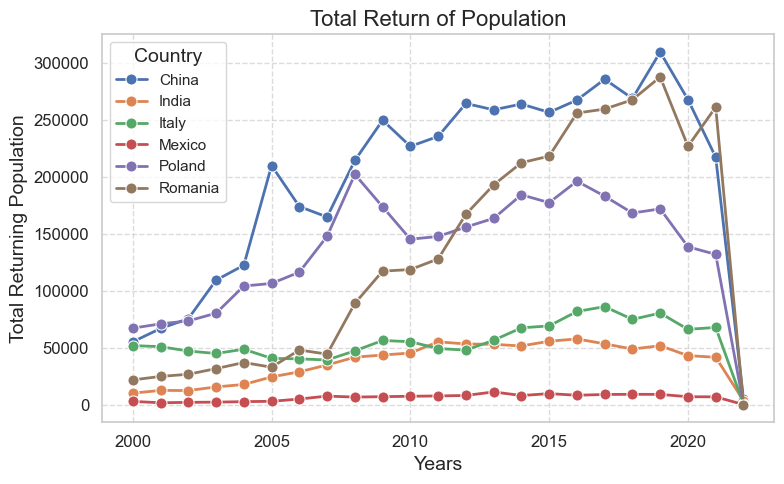

In [ ]:
#| label: fig-select-returns
#| fig-cap: ' Total return of native populations over time'

# selecting countries with top returns
top_countries = ['China', 'Poland', 'Romania', 'Italy', 'India', 'Mexico']
outlfows_top_countries = outflows_cleaned[outflows_cleaned['Country of birth/nationality'].isin(top_countries)]

# plotting a line graph graph
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

# plots total return for a given year and country
sns.lineplot(data=outlfows_top_countries, x="Year", y="Value", hue="Country of birth/nationality", estimator=sum, errorbar = None, marker="o", markersize=8, linewidth=2)

plt.title("Total Return of Population", fontsize=16)
plt.xlabel("Years", fontsize=14)
plt.ylabel("Total Returning Population", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.7)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Country", title_fontsize='14', loc='upper left')
plt.tight_layout()
plt.show()

Some of the countries we studied tend to have increasing return populations (China, Romania, and Poland) while other countries (India, Mexico, and Italy) did not show any significant changes in the number of returning populations. The countries with higher return rate have higher immigration rate, but these populations emigrated to nearby locations. Similar cultures, smaller distances, or improvements over time within the birth country can ease such back-and-forth movements among these migrating populations.

::: {.callout-warning}
The returning pupulation around 2020 falls to 0 for all the countries. This is most likely inconsistency in record keeping during the COVID-19 or due to the travel restrictions of that time.
:::

### Economic Involvements of Migrating Population

#### Employment Among Non-native Population

One of the reasons that can explain migration is the lack of employment opportunities in the birth countries of migrating populations. So migrating populations seek employment overseas. Without being employed, on the other hand, it might not be possible for an individual to survive in a new economy too. @fig-fbemployment shows the employment rate among non-native population based on their education level.

@fig-fbemployment-1 shows the employment rate is higher among highly-educated foreign-born populations compared to moderatly or low-educated poupulations. The ordered employment rate among foreign-born populations based on their education level makes sense. Although we don't have data to explore in this blog, there has been research indicating that the migrating populations on average don't tend to impact the overall literacy rate of the places in which they are moving. Educated migrants compensate for the uneducated.


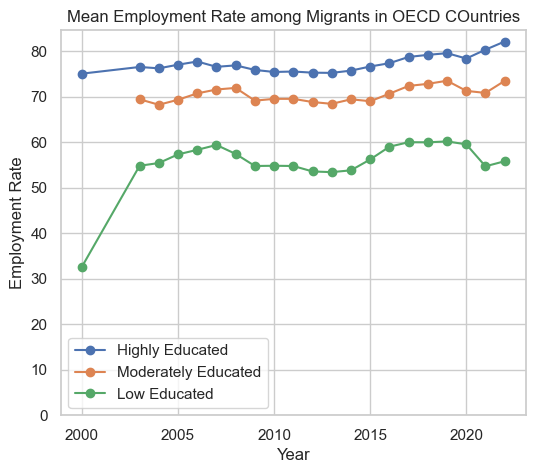

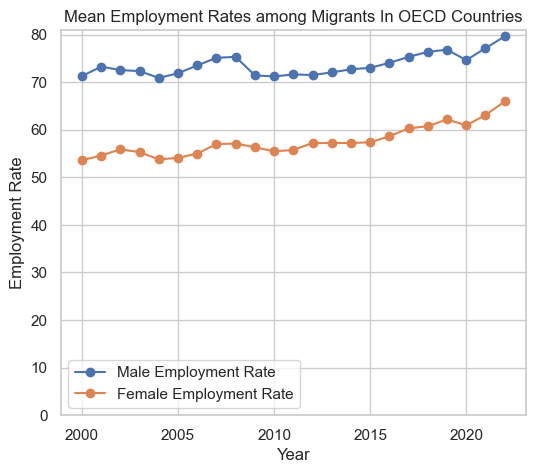

In [ ]:
#| label: fig-fbemployment
#| fig-cap: Total Employment Rate among Foreign-born Populations Over Time
#| fig-subcap:
#|   - by Education
#|   - by Gender
#| layout-ncol: 2

employment_by_place_edu = pd.read_csv("../data/MIG_EMP_EDUCATION_22022024161838929.csv")
# dropping unwanted columns
employment_by_place_edu = employment_by_place_edu.drop(columns=employment_by_place_edu.columns[[12, 13, 15, 16]])

# dropping some row values that we don't need.
unwanted_values = ['Total', 'European Union (27 countries)', 'European Union (28 countries)']
employment_by_place_edu = employment_by_place_edu[~employment_by_place_edu['Educational attainment'].isin(unwanted_values)]

employment_by_place_edu = employment_by_place_edu.sort_values(by='Value', ascending=False)

# plotting linegraph figures 

# by educational attainment

# mean employment rate for a given year
employment_by_year = employment_by_place_edu[employment_by_place_edu['BIRTH'] != "NB"].groupby(['Year', 'Educational attainment'])['Value'].mean().reset_index()

plt.figure(figsize=(6, 5))

high_employment_rate = employment_by_year[employment_by_year['Educational attainment'] == "High"]
medium_employment_rate = employment_by_year[employment_by_year['Educational attainment'] == "Medium"]
low_employment_rate = employment_by_year[employment_by_year['Educational attainment'] == "Low"]

# plotting line graph for each level of education
plt.plot(high_employment_rate['Year'], high_employment_rate['Value'], marker='o', label='Highly Educated')
plt.plot(medium_employment_rate['Year'], medium_employment_rate['Value'], marker='o', label='Moderately Educated')
plt.plot(low_employment_rate['Year'], low_employment_rate['Value'], marker='o', label='Low Educated')

plt.ylim(0) 
plt.title('Mean Employment Rate among Migrants in OECD COuntries')
plt.xlabel('Year')
plt.ylabel('Employment Rate')
plt.grid(True)
plt.legend()
plt.show()


# by gender
employment_by_gender_birth = pd.read_csv("../data/employment_birth_sex.csv")
employment_by_gender_birth['Country'] = employment_by_gender_birth['Country'].str.strip()

# just filtering OECD rates
OECD_total = employment_by_gender_birth[employment_by_gender_birth['Country'] != "OECD - Total"]

#plotting the emp rate
plt.figure(figsize=(6, 5))

male_employment_rate = OECD_total[(OECD_total['RATE'] == "N_RATE") & (OECD_total['Gender'] == 'Men') & (OECD_total['BIRTH'] == 'FB')]
male_employment_rate = male_employment_rate.groupby('Year')['Value'].mean()
plt.plot(male_employment_rate.index, male_employment_rate.values, marker='o', label='Male Employment Rate')

female_employment_rate = OECD_total[(OECD_total['RATE'] == "N_RATE") & (OECD_total['Gender'] == 'Women') & (OECD_total['BIRTH'] == 'FB')]
female_employment_rate = female_employment_rate.groupby('Year')['Value'].mean()
plt.plot(female_employment_rate.index, female_employment_rate.values, marker='o', label='Female Employment Rate')

plt.ylim(0) 
plt.title('Mean Employment Rates among Migrants In OECD Countries')
plt.xlabel('Year')
plt.ylabel('Employment Rate')
plt.grid(True)
plt.legend()
plt.show()

@fig-fbemployment-2 shows that the employment rate is higher among male populations than the female counterparts. Some argues that employers prey on migrants and use them as low-wage workers while others argue that the migrants tolerate toxic behaviors in workplaces, decreasing the overall moral standards in the work environments. I will say why not point fingers out to the overall economic incentives, both rewards and punishments, of locations in question that allow such tendencies. Such issues are serious violations of human rights and morality and have to be further investigated.


#### Remittance

One of the often overlooked characteristics of migration is remittance. While employment opportunities are what tie the immigrants to their destinations, remittance is what ties them still to their brith nations.
Remittance, as mentioned earlier, is defined as the sum of money sent by a person working abroad back to their birth country.

@fig-remit10 shows the top 10 nations recieving money from their citizens working abroad. This is consistent with emigrating populations we explored above. India, Mexico, Philippines, and China were the top moving populations during 2000-2020 as shown in @fig-topmeans.


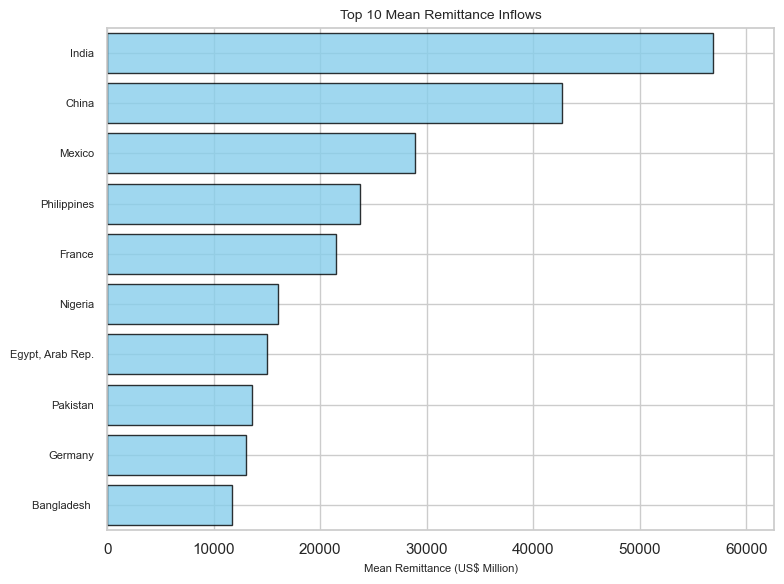

In [ ]:
#| label: fig-remit10
#| fig-cap: Top 10 countries receiving remittance (mean of 2000-2023 inflows)
# remittance inward flow

remit_inward = pd.read_excel("../data/inward_remittance_flows_december_2023_1.xlsx")

#calculate mean remittance
remit_inward['Mean Remittance'] = remit_inward.iloc[:, 1:-1].mean(axis=1)

# exclude groups of nations to focus on individual countries
remit_inward = remit_inward[(remit_inward['Remittance inflows (US$ million)'] != 'World') & 
                             (remit_inward['Remittance inflows (US$ million)'] != 'Low-and Middle-Income Countries')]

# included only top 10
top_10_remit_inward = remit_inward.nlargest(10, 'Mean Remittance')
top_10_remit_inward_sorted = top_10_remit_inward.sort_values(by='Mean Remittance', ascending=False)

# plot the figure
plt.figure(figsize=(8, 6))  # Adjusted figure size

countries = top_10_remit_inward_sorted['Remittance inflows (US$ million)']
mean_remittance = top_10_remit_inward_sorted['Mean Remittance']

# Define the position of bars on y-axis
y_pos = range(len(countries))

# Define the width of each bar based on 'Mean Remittance'
bar_width = mean_remittance * 0.01 

plt.barh(y_pos, mean_remittance, color='skyblue', height=0.8, edgecolor='black', linewidth=1, alpha=0.8)

plt.yticks(y_pos, countries, fontsize=8)
plt.xlabel('Mean Remittance (US$ Million)', fontsize=8) 
#plt.ylabel('Countries Receiving Remittance', fontsize=8)
plt.title('Top 10 Mean Remittance Inflows', fontsize=10)


plt.xlim(0, mean_remittance.max() * 1.1)
plt.ylim(-0.5, len(countries) - 0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Just because a country is receiving a huge sum of money as a remittances does not necessarily mean that the country is relying on remittance. Some countries have larger economies and populations where even a huge remittance does not contribute much to the whole. One such factor to account for the contribution to the economy of a country is to examine how much remittance contributed towards the GDP of a given year. There might be countries which are much more dependent on the remittances even though they don't have much populations working abroad as shown in @fig-remdep.


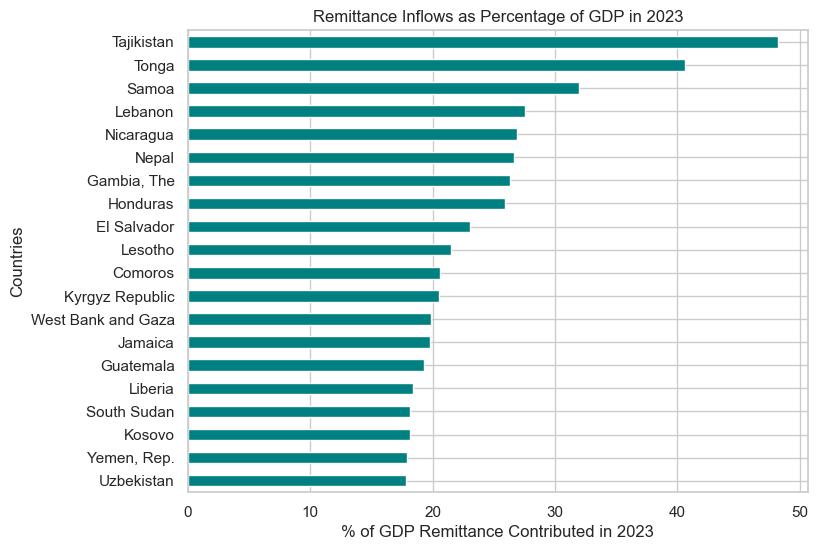

In [ ]:
#| label: fig-remdep
#| fig-cap: Top countries where GDP hugely depends on remittance

# largest economies based on the remittance contribution in %GDP 
top_10_gdp = remit_inward.nlargest(20, "% of GDP in 2023")
fig, ax = plt.subplots(figsize=(8, 6))

top_10_gdp_sorted = top_10_gdp.sort_values('% of GDP in 2023', ascending=True)
top_10_gdp_sorted.plot(y='% of GDP in 2023', x='Remittance inflows (US$ million)', kind='barh', ax=ax, color='teal', legend=False)
ax.set_xlabel('% of GDP Remittance Contributed in 2023')
ax.set_ylabel('Countries')
ax.set_title('Remittance Inflows as Percentage of GDP in 2023')
ax.set_yticklabels(top_10_gdp_sorted['Remittance inflows (US$ million)'])
plt.show()

@fig-remdep shows the countries hugely relying on remittance for their GDP for the fiscal year 2023. We see countries like Tajikstan, Samoa, and Nepal from where we did not see large exits in the above sections. 


### Decoding Sentiments Related to Migrations

For the sentimental analysis, texts were extracted from few selected PDF files @tip-articles. The NTLK library tokenizes the text, and uses the NRC Emotion Lexicon to identify and count the emotions associated with the tokenized words in the text. The sentiment scores across multiple PDFs were aggregated and visualized the overall sentiment distribution in the @fig-sentiment

![Distribution of Sentiments in the Selected Articles](sentimental_disstribution%20copy.png){#fig-sentiment}

::: {.callout-note}
This sentiment analysis was adapted from @K_2023. The code can be found at [/src/sentiment_analysis.ipynb](https://github.com/nishbh01/Migration-Our-Story-as-a-Mobile-Species/blob/main/src/sentiment_analysis.ipynb).
:::

This pie chart provides an overview of the emotional landscape surrounding the topic of migration. 

:::{.callout-caution}
It is limited by the choices of article and is a subjective analysis.
::: 
The chart shows that 28.8% of the sentiments reflect positive sentiments. The next largest sentiment is trust, at 14.4%. The percentages for negative sentiments (12.6%) is quite low compared to the positive sentiments--which is surprising given the negativities surrounding migration in everyday news.


In addition to the sentimental analysis, @fig-worded showcases various concepts and themes related to migration. 

![Mutually Covered Topics in the Selected Articles](wordcloud_high_quality.png){#fig-worded}


This word cloud provides an overview of the diverse topics and concepts interlinked with the complex phenomenon of international migration, including its underlying causes ("labour"), geographic patterns ("southern asia", "sub-saharan africa", "latin america""), economic dimensions("remittance", "income"), policy implications ("policy", "united nations" ), and human impacts ("conflict", "family", "refugees", "asylum seekers").

 

::: {#tip-articles .callout-tip title="Articles used in this analysis" collapse="true"}
* [UK starts detaining asylum seekers to be deported to Rwanda](https://www.aljazeera.com/news/2024/5/1/uk-starts-detaining-asylum-seekers-to-be-deported-to-rwanda) @AlJazeera_2024
*  [A quieter border eases pressure on Biden, with a hand from Mexico](https://www.washingtonpost.com/immigration/2024/04/30/united-states-mexico-border-surge-biden/) @Miroff_2024
* [German immigration policy: What's changing in 2024?](https://www.dw.com/en/german-immigration-policy-whats-changing-in-2024/a-67753472) @Pieper_2024
* [Nearly 900 Million Worldwide Wanted to Migrate in 2021](https://news.gallup.com/poll/468218/nearly-900-million-worldwide-wanted-migrate-2021.aspx) @Pugliese_Ray_2023
* Mcewan, C. (2004). Transnationalism. In A Companion to Cultural Geography (eds J.S. Duncan, N.C. Johnson and R.H. Schein). https://doi.org/10.1002/9780470996515.ch32 @doi:https://doi.org/10.1002/9780470996515.ch32
* [MIGRATION AND TRANSNATIONALISM: OPPORTUNITIES AND CHALLENGES](https://www.iom.int/sites/g/files/tmzbdl486/files/jahia/webdav/shared/shared/mainsite/microsites/IDM/workshops/migration_and_transnationalism_030910/background_paper_en.pdf)
* [The Future of Migration](https://www.dni.gov/files/images/globalTrends/GT2040/NIC-2021-02486--Future-of-Migration--Unsourced--14May21.pdf)
* [Is migration good for the economy?](https://www.oecd.org/migration/OECD%20Migration%20Policy%20Debates%20Numero%202.pdf)
* [International Migration: Drivers, Factors and Megatrends](https://www.icmpd.org/file/download/51472/file/Policy%2520Paper%2520-%2520Geopolitical%2520Outlook%2520on%2520International%2520Migration.pdf) @chintescu2023international
* [International Migration 2020 Highlights](https://www.un.org/development/desa/pd/sites/www.un.org.development.desa.pd/files/undesa_pd_2020_international_migration_highlights.pdf)
:::

### Clustering the Differences in Migrations across Years and Countries 

It was very interesting to see the overall trend since 2000 in migration patterns in the above sections. It would also be interesting to analyze if there are certain years or countries that share the same pattern of how people move. For this K-means clustering was used from scikit-learn library. It was figured out that the four clusters tend to account for the overall variability in the number of moving populations: clusters that achieve lower differences in observations within the same clusters but maintain higher inter-cluster distances.


In [8]:
#| label: fig-kmeans
#| fig-cap: Observations grouped in K-means Clusters for every year

# subset of data
df = inflows_cleaned[['Country of birth/nationality', 'Country', 'Year', 'Value']].copy()

# k means clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# specifying the number of clusters (k)
# determined using elbow plot # look at the  clustering.ipynb notebook for detail
k = 4

# Fit K-means clustering algorithm
kmeans = KMeans(n_clusters=k)
kmeans.fit(df[['Value']])

# Add cluster labels to the DataFrame
df['cluster_label'] = kmeans.labels_.astype(int) #confounding them as integer show that can be ordered

# Reorder cluster labels so that label '3' corresponds to the largest observations
df.loc[:, 'cluster_label'] = df['cluster_label'].map({
    label: idx for idx, label in enumerate(np.argsort(kmeans.cluster_centers_.flatten()))
})

# Visualize the clusters
plt.figure(figsize=(9, 7))
scatter = plt.scatter(df['Value'], df['Year'], c=df['cluster_label'])

unique_labels = np.unique(df['cluster_label'])

# colormap used in the scatter plot--> for labelling
cmap = plt.colormaps.get_cmap(scatter.get_cmap())

cluster_colors = {}

# Extract colors for each cluster label
for label in unique_labels:
    cluster_colors[label] = cmap(label / (len(unique_labels) - 1))

for label, color in cluster_colors.items():
    plt.scatter([], [], color=color, label=f'Cluster {label}')

plt.legend(loc='upper right', scatterpoints=1, title='Clusters')

plt.xlabel('Migration Values for a given year')
plt.ylabel('Year')
plt.title('K-means Clusters of Countries')

plt.show()

NameError: name 'inflows_cleaned' is not defined

@fig-kmeans shows almost consistent patterns in migrating populations throughout the years. Cluster 0 to Cluster 3 are odered in ascending order, indicating the total number of people moving from one country to another. Years before 2005 have few observations in Cluster 3, meaning there were not that many migrant groups with a large number of people. From 2015-2020 there are some observations that are very different from others, even if they belong to the same Cluster 3. Even if we don't see any pattern through Clusters 0, 1, and 2, Cluster 3 shows some patterns across years: fewer large migrations before 2005, similar large migrations in 2005-2015, and few larger migrations around 2015-2020. 

In addition to the differences over time, we will also look at the differing patterns among destination countries. Note that our data only covers OECD countries as potential destinations for migrants.


In [ ]:
#| label: fig-kmeans_country
#| fig-cap: Observations grouped in K-means Clusters for destinations

# doing the figure for destinations
plt.figure(figsize=(8, 18))
scatter = plt.scatter(df['Value'], df['Country'], c=df['cluster_label'])

unique_labels = np.unique(df['cluster_label'])

# colormap used in the scatter plot
cmap = plt.colormaps.get_cmap(scatter.get_cmap())

cluster_colors = {}

# Extract colors for each cluster label
for label in unique_labels:
    cluster_colors[label] = cmap(label / (len(unique_labels) - 1))

for label, color in cluster_colors.items():
    plt.scatter([], [], color=color, label=f'Cluster {label}')

plt.legend(loc='upper right', scatterpoints=1, title='Clusters')

plt.xlabel('Migration Values for a destination')
plt.ylabel('Destinations')
plt.title('K-means Clusters of Countries')
plt.show()

@fig-kmeans_country shows different countries have differing movements over time. Only a few countries have observations in Cluster 3 which represents the largest moving populations. We can examine the clusters that classify the inflows in different countries.


In [ ]:
# prints destinations present in a cluster
for cluster in df['cluster_label'].unique():
    print(f"Cluster {cluster}:")
    print(df[df['cluster_label'] == cluster]['Country'].unique().tolist()) # return as a list

Only `'Japan', 'Korea', 'Canada', 'United States', 'Germany', 'Italy', 'Spain', 'Poland', and 'Chile'` are in the Cluster 3. This is consistent with our findings in earlier sections. These countries tend to be the top destinations for migrants. In addition, in @fig-kmeans we observed that after 2015, there were big movements in some countries. From @fig-kmeans_country, it can be deduced that Germany and the United States may be the countries that have the largest inflows. These two figures can be coupled to study the patterns of migrations across years and destinations.


### Schengen vs Non-Schengen: An Analysis of differing philosophies in human mobility

It is important to understand how migration trends differ from one country to another, or from one region to another. In this section we examine the complexity of migration trends and clarify the implications of policies related to human mobility. We will analyze the different views on migration trends between Schengen countries with borderless travel among participating European nations and control nations with more conventional immigration policy. We will only use a subset of five non-schengen countries--'Australia', 'Canada', 'Japan', 'New Zealand', 'United States'--and five schengen countries--'Germany', 'France', 'Greece', 'Spain', 'Italy'. 


In [ ]:
#| label: fig-schen
#| fig-cap: Comparision of inflowing populations in schengen and non-schengen countries

import warnings
warnings.filterwarnings('ignore')

flows = pd.read_csv("../data/inflows of foreign population by nationality.csv", low_memory=False)

flows = flows.dropna(subset=['Value'])
flows_cleaned = flows.dropna(subset=['Value'])

# dropping columns that we don't need
flows_cleaned = flows.drop(columns=['Flag Codes', 'Flags'])
flows_cleaned = flows_cleaned[flows_cleaned['Country of birth/nationality'] == "Total"]
flows_cleaned = flows_cleaned[(flows_cleaned['Variable'] == 'Inflows of foreign population by nationality') | (flows_cleaned['Variable'] == 'Outflows of foreign population by nationality')]
flows_cleaned = flows_cleaned[['Country', 'Year', 'Variable', 'Value']]

# selecting only few countries in both groups
schengen_countries = ['Germany', 'France', 'Greece', 'Spain', 'Italy']
non_schengen = ['Australia', 'Canada', 'Japan', 'New Zealand', 'United States']
schengen_non = flows_cleaned[flows_cleaned['Country'].isin(schengen_countries + non_schengen)]

# add a column that classifies each country as schengen or non-schengen
def is_schengen(country):
    if country in schengen_countries:
        return 'Schengen'
    else:
        return 'Non_Schengen'

# applying the func
schengen_non.loc[:, 'Schengen'] = schengen_non['Country'].apply(is_schengen)
# Filter the DataFrame to include only the rows where the variable is 'Inflows of foreign population by nationality'
inflows_df = schengen_non[schengen_non['Variable'] == 'Inflows of foreign population by nationality']
#outflows
outflows_df = schengen_non[schengen_non['Variable'] == 'Outflows of foreign population by nationality']

# Group the data by the 'Schengen' column and calculate the total migration flow for each group
migration_comparison = inflows_df.groupby('Schengen')['Value'].sum()

# plotting
# emigrating population
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['b' if s == 'Schengen' else 'r' for s in inflows_df['Schengen']]

# Create separate scatter plots for each group
schengen = ax.scatter(inflows_df.loc[inflows_df['Schengen'] == 'Schengen', 'Year'],
                      inflows_df.loc[inflows_df['Schengen'] == 'Schengen', 'Value'],
                      c='b', alpha=0.5, label='Schengen')

non_schengen = ax.scatter(inflows_df.loc[inflows_df['Schengen'] == 'Non_Schengen', 'Year'],
                          inflows_df.loc[inflows_df['Schengen'] == 'Non_Schengen', 'Value'],
                          c='r', alpha=0.5, label='Non Schengen')

# Add legend
ax.legend(handles=[schengen, non_schengen])

ax.set_xlabel('Year')
ax.set_ylabel('Emigrating Population')
ax.set_title('Total Inflows of Foreign Population in selected Schengen and non-Schengen Countries')
plt.show()

As shown in @fig-schen, throughout the years, there are not much differences in inflows of foreign population among the selected Schengen and non-Schengen countries. From previous sections, we can say Germany is the Schengen country with the largest migrations around 2015. The non-schengen country with a slightly lower inflowing population than that of Germany is probably the United States. Next we will explore the return of non-native population from these two groups.


In [ ]:
#| label: fig-schen_out
#| fig-cap: Comparision of returning populations from schengen and non-schengen countries

# foreign_population leaving (outflows_df)
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['b' if s == 'Schengen' else 'r' for s in outflows_df['Schengen']]

# Create separate scatter plots for each group
schengen = ax.scatter(outflows_df.loc[outflows_df['Schengen'] == 'Schengen', 'Year'],
                      outflows_df.loc[outflows_df['Schengen'] == 'Schengen', 'Value'],
                      c='b', alpha=0.5, label='Schengen')

non_schengen = ax.scatter(outflows_df.loc[outflows_df['Schengen'] == 'Non_Schengen', 'Year'],
                          outflows_df.loc[outflows_df['Schengen'] == 'Non_Schengen', 'Value'],
                          c='r', alpha=0.5, label='Non Schengen')

# Add legend
ax.legend(handles=[schengen, non_schengen])

ax.set_xlabel('Year')
ax.set_ylabel('Returning Population')
ax.set_title('Outflows of foreign population in Selected Schengen and non-Schengen Countries')

plt.show()

@fig-schen_out shows some patterns in the return of non-native populations between Schengen and non-Schengen countries. There tends to be more returns from multiple Schengen countries. We have seen multiple larger returns from Schengen countries in @fig-returns-total as well. This can have multiple explanations. Schengen countries tend to get more migrants from other Schengen countries while countries like the US and Canada tend to have inter-continental migrants. These kinds of migration patterns can also explain the mindsets of migrants when it comes to returning to their birth countries. 

# Conclusions

The analyses over the last 20 years of data revealed a number of noteworthy patterns and trends in the dynamics of global migration. Major destinations that continuously draw large inflows from a variety of countries are the United States and Germany. It's interesting to note that immigrants from relatively stable countries typically had a stronger tendency to return home, whereas migrants escaping political turbulence and economic instability tended to pursue naturalization in their new country. The geographic separation and cultural differences between the countries of origin and the places of destination also affect the return rate. People have a tendency to return if they relocate to adjacent, culturally comparable countries. Additionally, there is a strong association between nations with sizable emigrant populations and remittance inflows. 

The examination of migration-related research papers found a prevalence of positive views, which could reflect a rising realization of the multiple benefits that come from human migration and the common experience we all share. Climate change, conflicts, and altering economic opportunities are expected to shape future migration trajectories, necessitating adaptive policy and international cooperation to address the challenges and opportunities associated with global migration. 


# Limitations

Although this analysis sheds light on patterns and trends in global migration, it is crucial to recognize that the data and technique employed in this study have certain limitations. The migration patterns in non-OECD regions are not captured as the data is limited to the destinations in OECD countries. Furthermore, while internal migration dynamics inside nations can also have a substantial impact on population distributions and socioeconomic aspects of a nation, the analysis is limited to international migration only. 

Data collection during and after the COVID-19 pandemic years appears to be incomplete, which could impair the accuracy of analysis conducted at the time. Undocumented migrations, which can make up a major portion of overall migration movements in some regions or nations, are also not taken into consideration by the data sources used in this analysis. 

Because of the nature of the data sources, the research is mostly based on aggregated migration numbers for nations, ignoring the nuanced differences in total populations and their composition across countries. Despite these limitations, the analysis provides useful insights into worldwide migration trends and identifies areas for future investigation and research. Future research could benefit from including more data sources, investigating qualitative variables impacting migration decisions, and using more granular spatial and temporal analysis to achieve a more complete picture of this ever-changing story of human mobility.


## Additional Figures

::: {#fig-flows}

<iframe width="560" height="700" src="migration_lines_overtime.html"></iframe>

Top Inflows of Migrants in OECD nations
:::